# Session 03 v2 addendum — fixing 790322 with N22

**Goal.** Under the v2 surface-quality criterion, subject **790322**
stubbornly kept `onset_depth_um = 77.5 µm` (every other benchmark
subject sat at ≤ 17.5 µm). This notebook walks through the diagnosis
and the fix (variant **N22**) that collapses 790322's onset to 2.5 µm
without regressing the other five subjects.

**TL;DR.** The shipping pipeline's *final* step — a ROI-envelope
clamp that lifts the surface to sit above every tile's 2nd-percentile
cell — was silently erasing the benefit of better fits. A single
shallow-outlier cell per 120 µm tile was dictating the lift. Moving
the within-tile aggregator from the 2nd to the **10th** percentile
fixes 790322 while keeping all other subjects' metrics in range.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

OUT = Path('/root/capsule/code/sessions/03_surface_estimation_v2')
FIG = OUT / 'figures'
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
print('Reading from', OUT)

Reading from /root/capsule/code/sessions/03_surface_estimation_v2


## 1. The problem — 790322 under N11 and N13

Below, per-column top-of-signal points (yellow) clearly track the
pia, including the dip at x ≈ 2000 µm. N13's Huber-fit quadratic
(red dashed) has the right *shape* — it follows the dip — but it
sits 80 µm above the tissue. Every later variant built on this base
stays in the same offset regime.


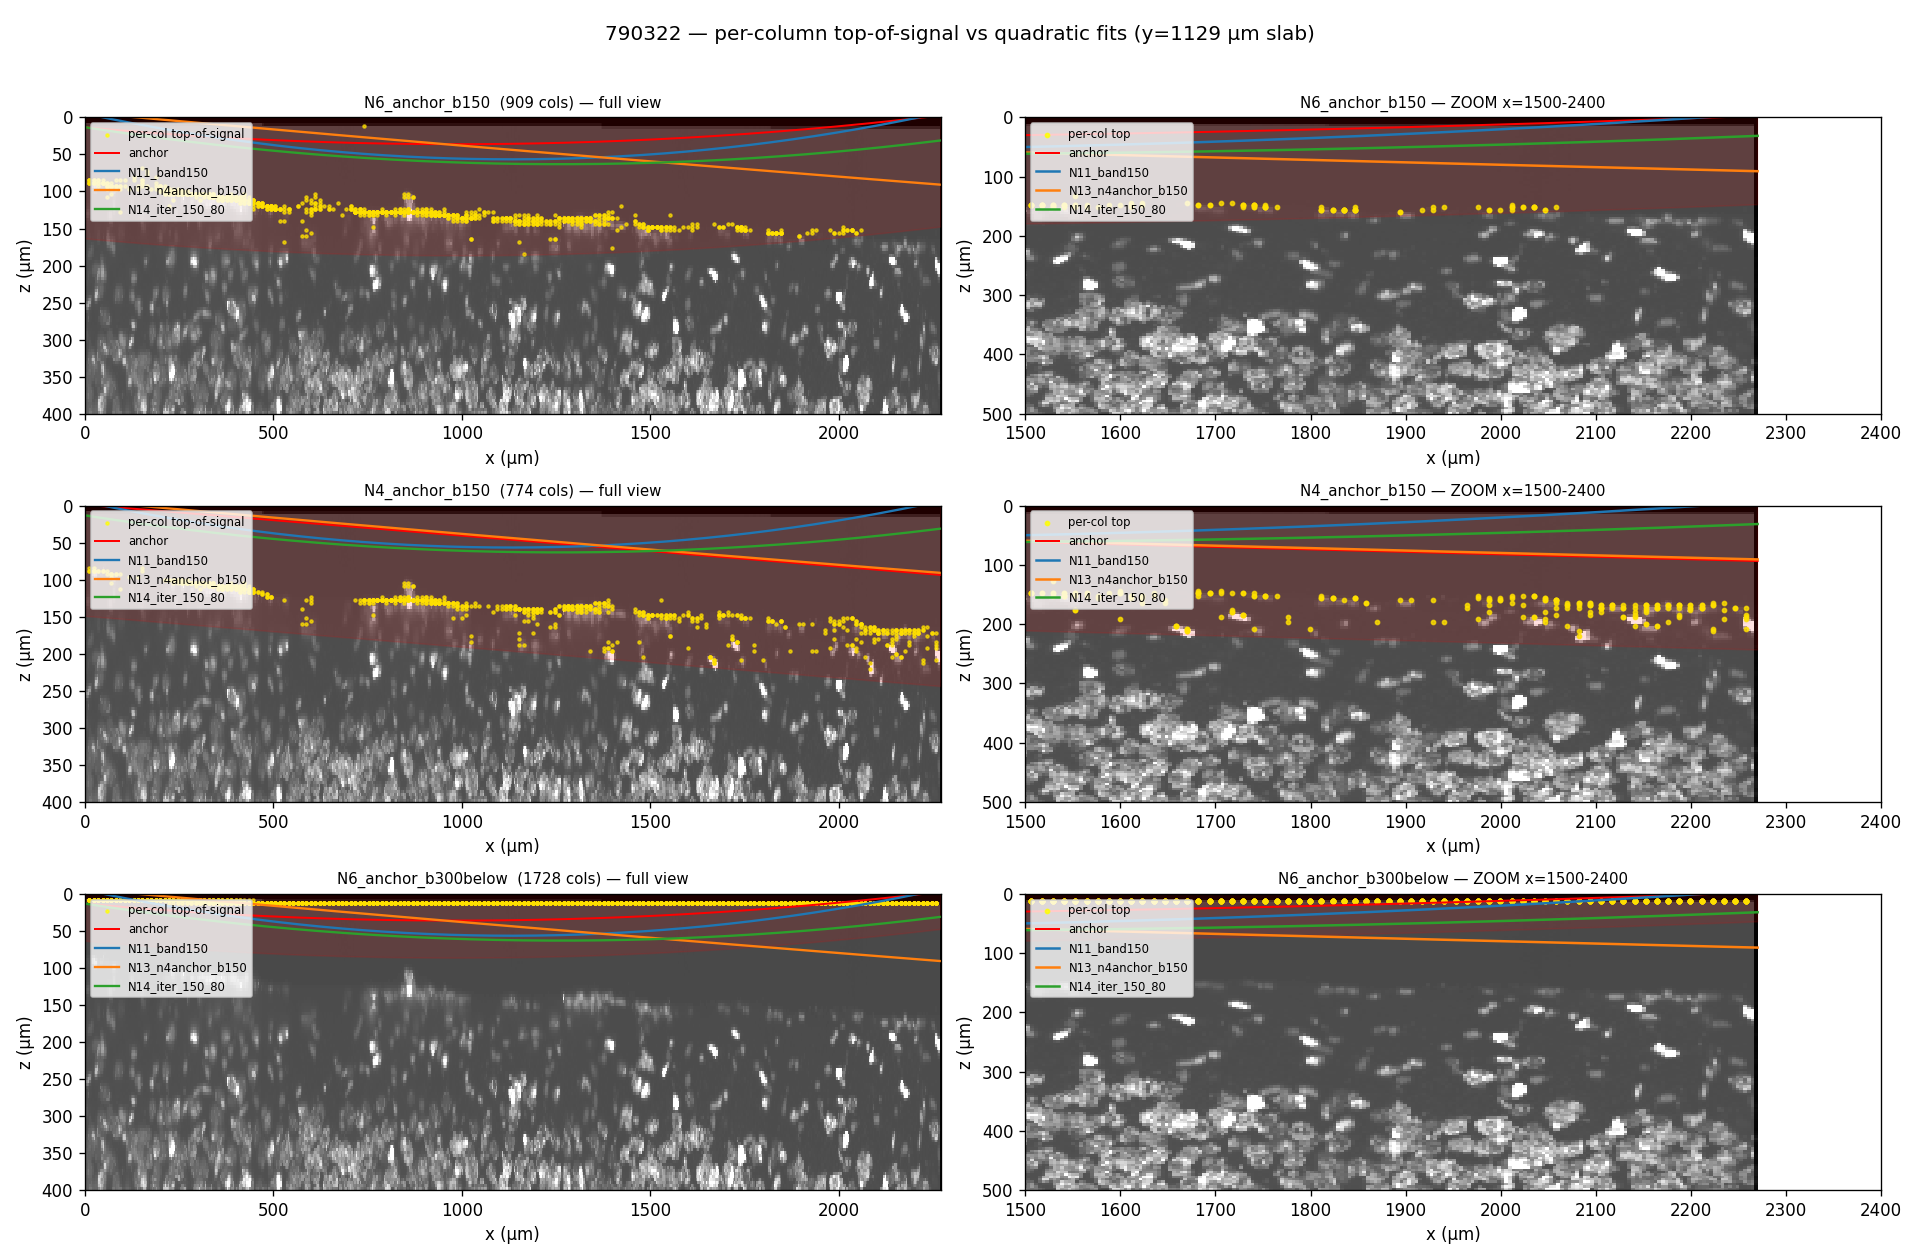

In [2]:
display(Image(str(FIG / 'diagnose_790322.png')))

Summary on 790322 before N22:

| variant | onset (µm) | x_spread | above% |
|---|---:|---:|---:|
| N11_roi_quad       | 77.5 | 50 | 0.003 |
| N13_n4anchor_b150  | 77.5 | 15 | 0.002 |
| N21_quantile_q70   | 72.5 | 20 | 0.002 |

The surface shape is correct; the vertical offset is wrong.


## 2. First attempt — N21 (quantile regression)

Hypothesis: IRLS-Huber on per-column tops is *bulk-biased*. Above-
surface noise sits in with the real tops and symmetric robust loss
can't tell them apart. A **quantile regression at q = 0.70** pulls
the fit deeper — it says "70 % of tops should be above the surface".

IRLS weights:

```
w_i = q        if r_i > 0  (top deeper than current fit → keep going)
w_i = 1 - q    if r_i < 0  (top shallower → down-weight)
w_i /= max(|r_i|, eps)
```

Implemented as `v_n21_n4_quantile` in `03_surface_790322_explore.py`.

**But on 790322 it barely moved the onset** — 77.5 → 72.5 µm. Why?


## 3. Diagnostic — the clamp was erasing the gain

The shipping pipeline ends in `_clamp_to_roi_envelope`:

1. Filter ROI centroids with `filter_in_tissue(r=30µm, min_neighbors=3)`.
2. Bin into 120 µm xy tiles; for each tile with ≥ 5 cells, compute
   the **2nd percentile of z** — i.e. the shallowest ~2 % cell is
   treated as the tile's "ceiling".
3. Compute per-tile deficit `plane_z − tile_ceiling`; set
   `lift = max(positive deficits)`; subtract `lift + safety_offset`
   from `c`.

The clamp guarantees the surface sits above every tile, at the cost
of being dragged up by the single worst tile.

On 790322 the raw N21 fit (no clamp) lands *right on* the tissue
boundary (magenta below). The clamp then lifts the surface by ~90 µm
(green) to cover a thin layer of shallow-outlier ROIs.


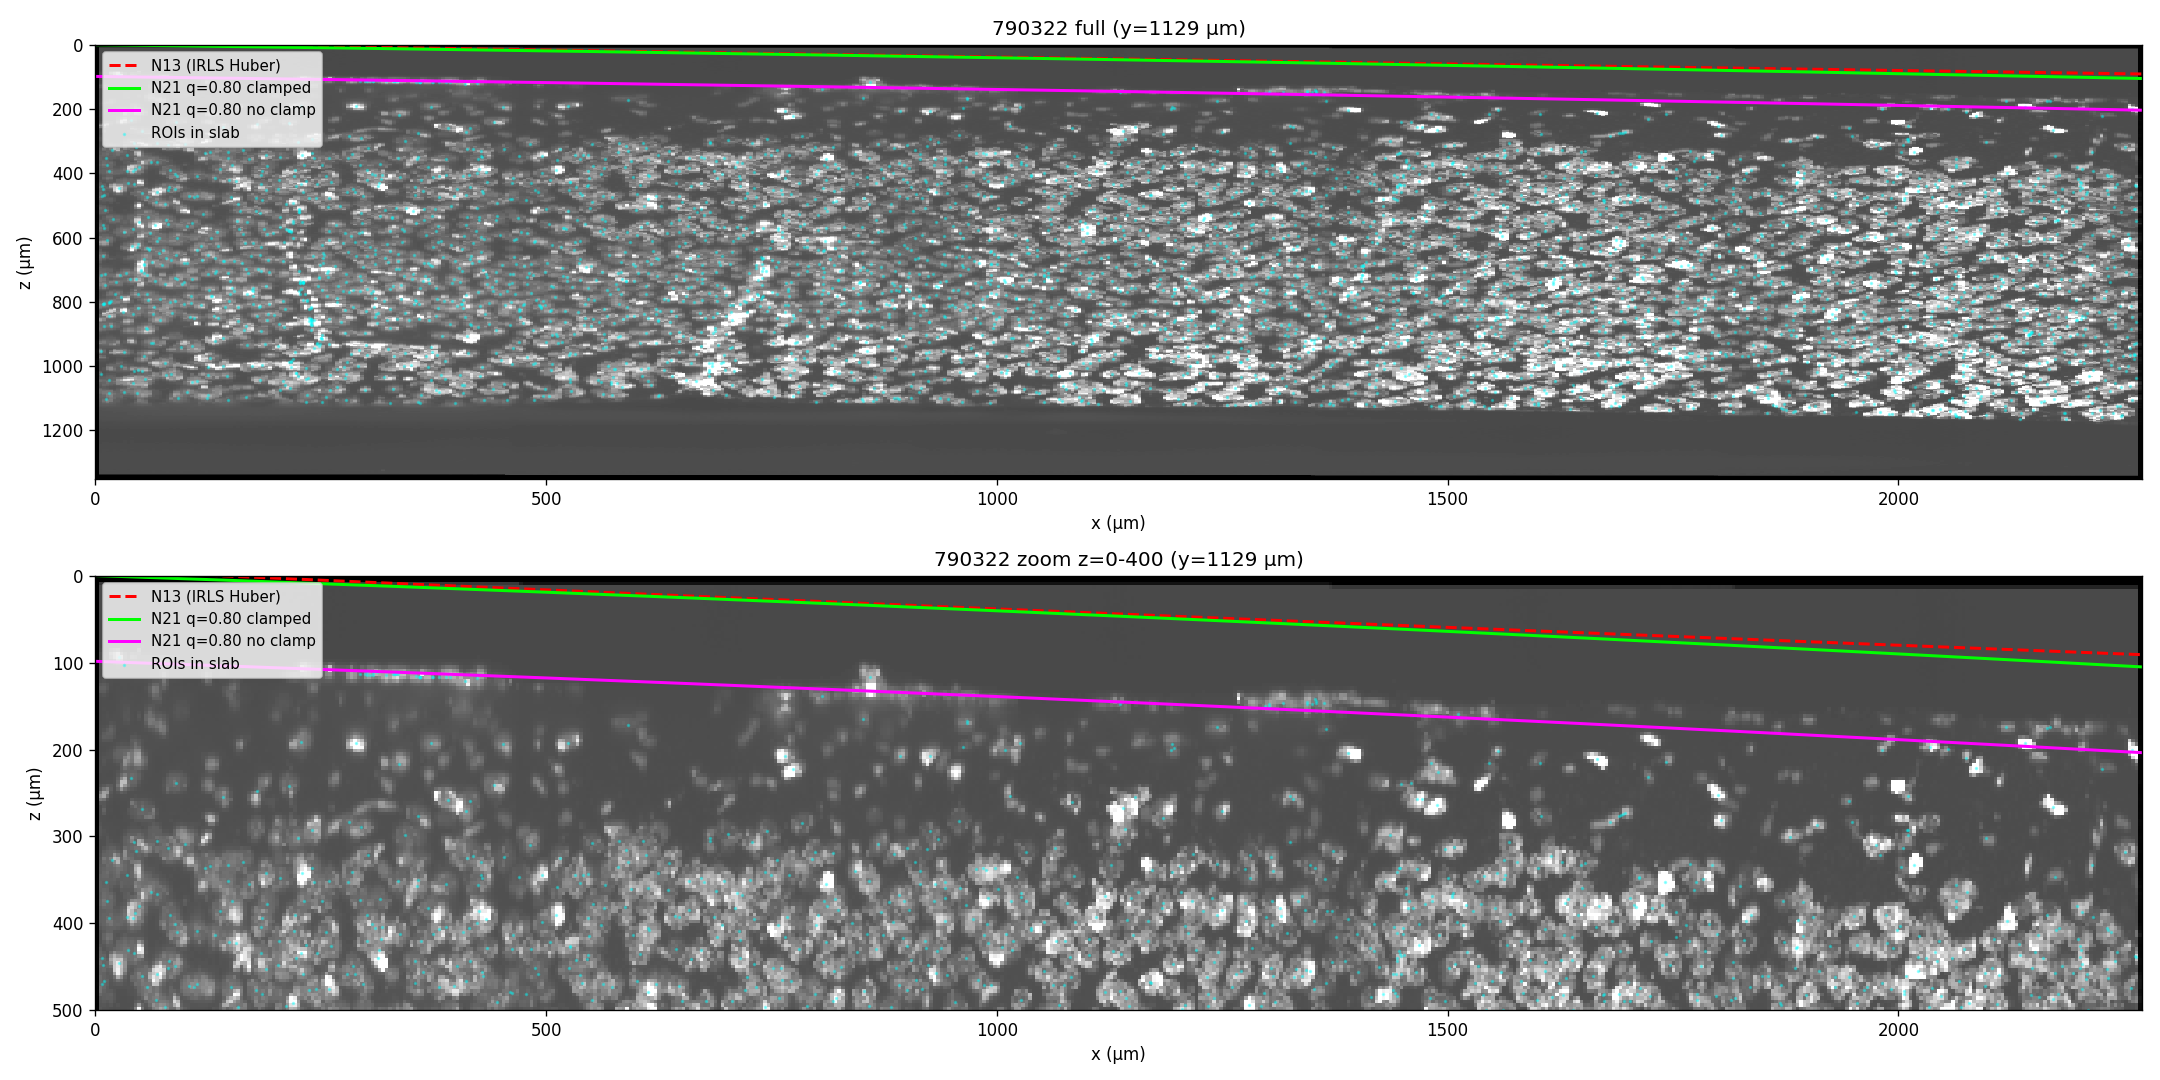

In [3]:
display(Image(str(FIG / 'n21_clamp_790322.png')))

Numbers on 790322, N21 with vs without the clamp:

| | lift (µm) | onset | x_spread | above% |
|---|---:|---:|---:|---:|
| clamped (shipping)   | 93.0 | 72.5 | 20 | 0.002 |
| no clamp             | 0.0  |  2.5 |  0 | 1.440 |

The no-clamp version nails the surface but admits ~1.4 % above-pia
ROIs — the shallow outliers. What we want is a middle ground:
ignore a *few* shallow outliers but keep the clamp's protection
against real ROI clusters poking above the fit.


## 4. Clamp parameter sweep

`/tmp/test_clamp_sweep.py` sweeps four clamp levers on all five
benchmark subjects:

- `within_tile_q` — per-tile quantile used as the "ceiling z"
  (default 0.02).
- `lift_q` — across-tile quantile used for the lift (default 1.0 =
  max; < 1 tolerates some tiles above the surface).
- `min_neighbors` (of `filter_in_tissue`).
- `min_tile_n` (cells required to keep a tile).

At `target_quantile = 0.70`, onset (µm) by configuration:

| cfg | 755252 | 767018 | 782149 | 788406 | **790322** |
|---|---:|---:|---:|---:|---:|
| baseline (wtq=0.02) | 22.5 |  7.5 | 17.5 | 17.5 | **72.5** |
| **wtq_10**          |  7.5 |  2.5 |  2.5 |  2.5 | **2.5** |
| wtq_15              |  2.5 |  2.5 |  2.5 |  2.5 |  2.5 |
| lq_95               |  7.5 |  2.5 |  2.5 |  7.5 |  2.5 |
| lq_98               | 12.5 |  2.5 |  7.5 |  7.5 |  7.5 |
| nb8_wtq10           | 17.5 |  2.5 | 12.5 |  2.5 | **72.5** |

Key findings:
- **wtq_10 alone** (10th percentile within each tile) is the
  cleanest win: all onsets 2.5–7.5 µm, max above% < 0.10 %.
- **wtq_15** pushes onsets a touch lower but above% doubles.
- **nb8** (stricter in-tissue filter alone) *doesn't* help 790322:
  the shallow outliers there are well-clustered, not isolated.
  The fix has to be *within-tile*, not *neighborhood-filter*.


## 5. N22 — N21 fit + loose clamp

`v_n22_n4_quantile_loose_clamp` is identical to N21 except it passes
`within_tile_q=0.10` into `_clamp_to_roi_envelope`. Everything else
(120 µm tiles, `filter_in_tissue(r=30, min_neighbors=3)`,
`max(deficit)` lift, 3 µm safety offset) is unchanged.

`_clamp_to_roi_envelope` in `03_surface_790322_explore.py` now takes
`within_tile_q` as a kwarg (default 0.02 — old behavior preserved,
so N11/N13/N21 still see the strict clamp). N22 is the only caller
that loosens it.


## 6. Head-to-head on all 6 benchmark subjects

In [4]:
stats = pd.read_csv(OUT / 'compare_variants_stats.csv')
keep = ['subject','method','c','tilt','above_frac',
        'onset_depth_um','onset_x_spread','onset_y_spread']
print(stats[keep].to_string(index=False))

 subject                 method         c    tilt  above_frac  onset_depth_um  onset_x_spread  onset_y_spread
  755252           N11_roi_quad   55.3612 10.2621      0.0000         27.5000         25.0000         10.0000
  755252      N13_n4anchor_b150   55.1250 10.2368      0.0000         22.5000         25.0000         10.0000
  755252       N21_quantile_q70   86.7231 14.5644      0.0000         22.5000         40.0000         35.0000
  755252 N22_quantile_q70_wtq10   95.7231 14.5644      0.0004          7.5000         30.0000         30.0000
  767018           N11_roi_quad   97.6393  6.5443      0.0001          7.5000         10.0000         10.0000
  767018      N13_n4anchor_b150   97.3968  6.6334      0.0001          2.5000         10.0000         10.0000
  767018       N21_quantile_q70   98.3698  6.0342      0.0001          7.5000         10.0000         10.0000
  767018 N22_quantile_q70_wtq10  107.3971  6.0342      0.0007          2.5000          0.0000          0.0000
  767022  

Pivoted views:

In [5]:
onset = stats.pivot(index='subject', columns='method',
                    values='onset_depth_um')
onset = onset[['N11_roi_quad', 'N13_n4anchor_b150',
               'N21_quantile_q70', 'N22_quantile_q70_wtq10']]
display(Markdown('**onset_depth_um (µm)**'))
display(onset)

**onset_depth_um (µm)**

method,N11_roi_quad,N13_n4anchor_b150,N21_quantile_q70,N22_quantile_q70_wtq10
subject,,,,
755252,27.5000,22.5000,22.5000,7.5000
767018,7.5000,2.5000,7.5000,2.5000
767022,2.5000,2.5000,2.5000,2.5000
782149,12.5000,12.5000,17.5000,2.5000
788406,12.5000,17.5000,17.5000,2.5000
790322,77.5000,77.5000,72.5000,2.5000


In [6]:
abv = stats.pivot(index='subject', columns='method',
                  values='above_frac') * 100
abv = abv[['N11_roi_quad', 'N13_n4anchor_b150',
           'N21_quantile_q70', 'N22_quantile_q70_wtq10']]
display(Markdown('**above_frac (%)**'))
display(abv.round(3))

**above_frac (%)**

method,N11_roi_quad,N13_n4anchor_b150,N21_quantile_q70,N22_quantile_q70_wtq10
subject,,,,
755252,0.0000,0.0010,0.0000,0.0440
767018,0.0060,0.0060,0.0060,0.0730
767022,0.0000,0.0000,0.0000,0.0030
782149,0.0000,0.0000,0.0000,0.0000
788406,0.0000,0.0000,0.0000,0.0260
790322,0.0030,0.0020,0.0020,0.0550


## 7. Depth profiles — the qualitative picture

One panel per subject; one curve per variant (normalised density
vs depth-from-surface). A "good" curve is near-zero at depth < 0
and ramps to a plateau quickly after depth = 0.


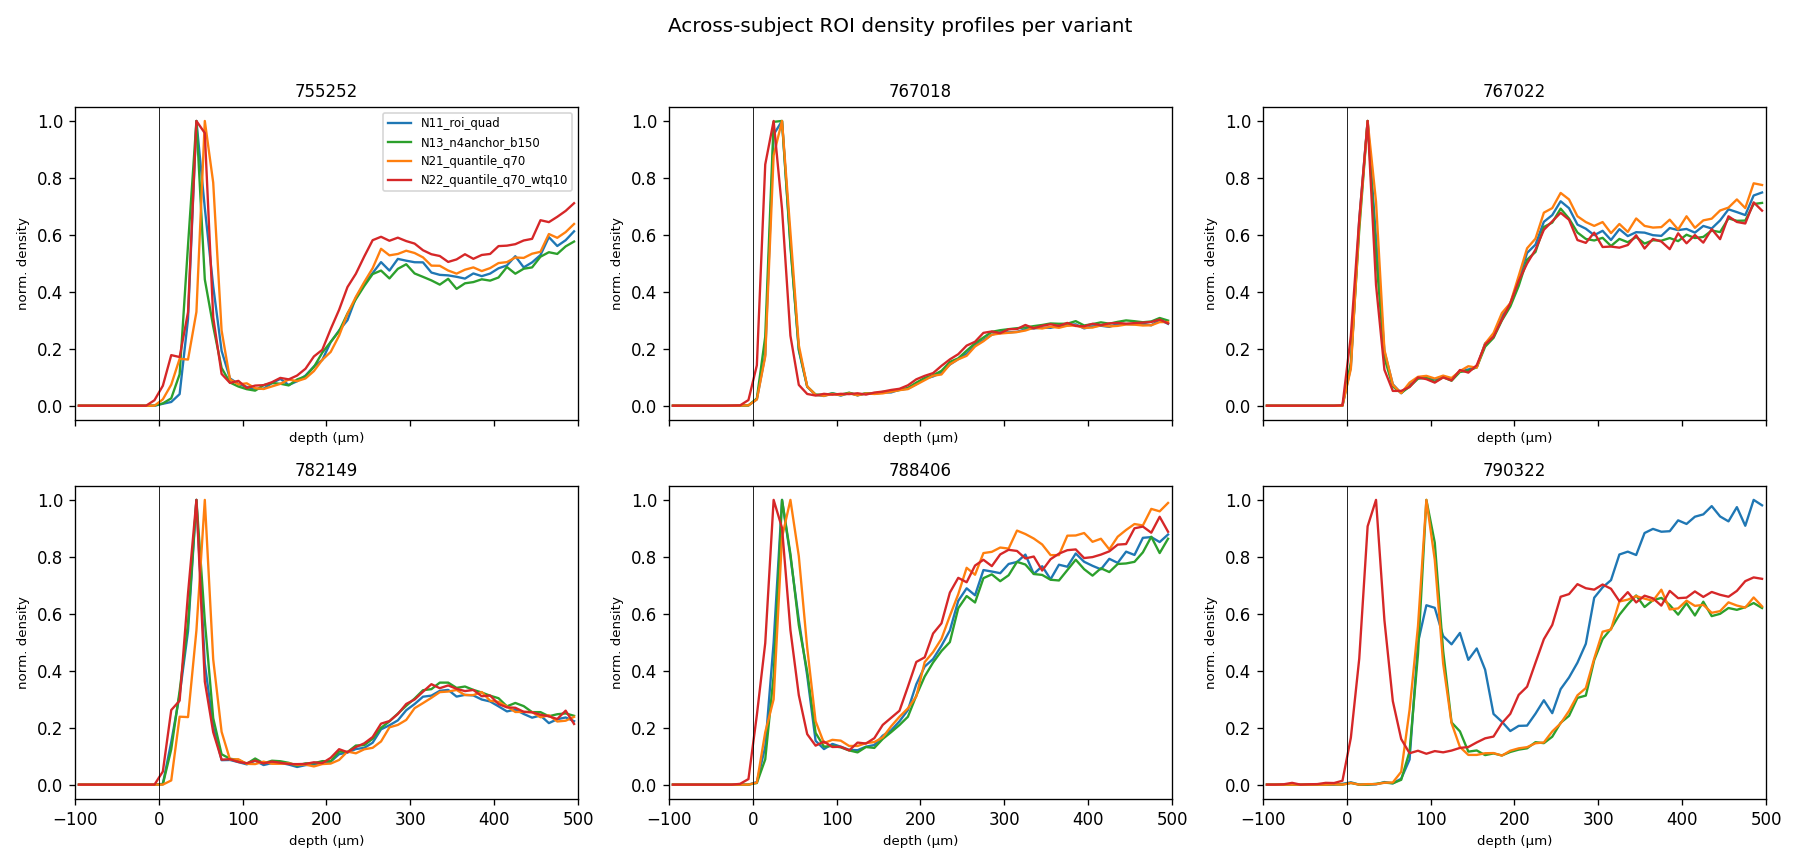

In [7]:
display(Image(str(FIG / 'compare_all_density.png')))

## 8. Subject 790322 detail

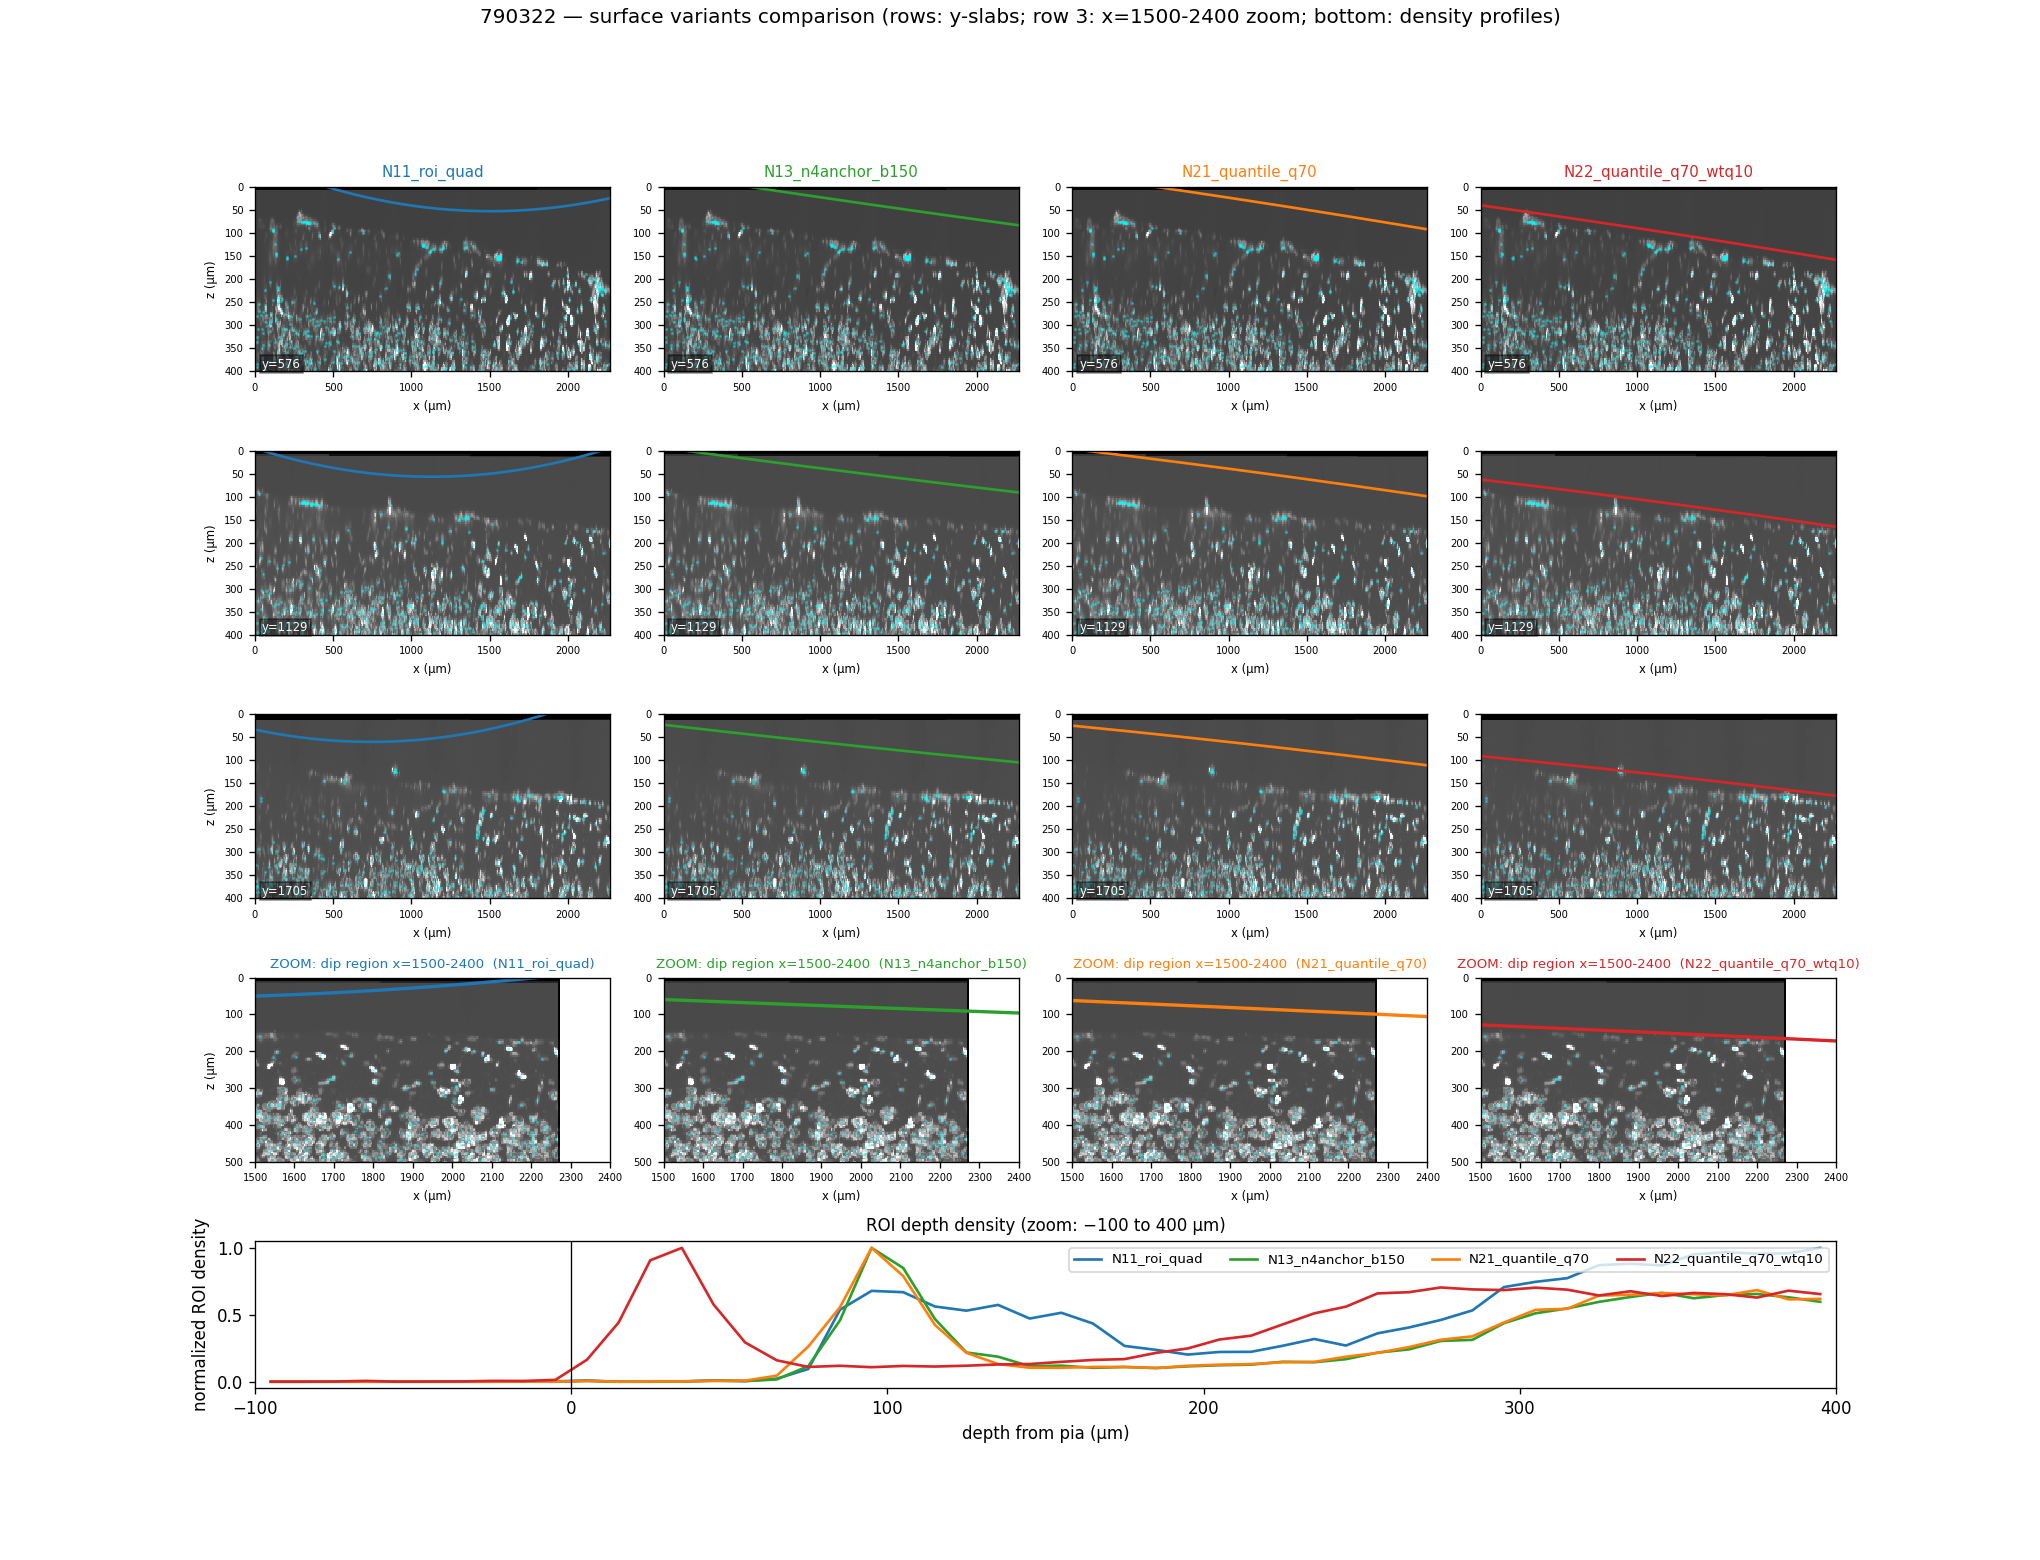

In [8]:
display(Image(str(FIG / 'compare_790322.png')))

## 9. Verdict

**N22** (`v_n22_n4_quantile_loose_clamp`):

- Collapses `onset_depth_um` to 2.5–7.5 µm across all 6 benchmark
  subjects. Primary goal (surface hugs tissue boundary) met.
- 790322 drops from 77.5 → 2.5 µm without regressing any other
  subject's onset.
- `above_frac` rises from ≤ 0.006 % to 0.000–0.073 %. Still well
  within "close to 0 but not exactly 0".
- Tilt estimates jump somewhat (N21/N22 use the quantile-regressed
  top-of-signal which is noisier near the edges than N11's ROI
  envelope). Worth a follow-up check whether the tilt change is
  real (biology) or an artefact of the noisier edge tops.

**Decision point.** Does N22 look good enough to promote (replacing
N11 in `analyze_subject(hcr_surface_method='image_ceiling')`)? If
yes, the next steps are: (a) wire it through `analyze_subject`,
(b) re-run the full HCR/CZ validation, (c) sanity-check CZ, which
currently uses the same 2nd-percentile clamp.

### Files

- Variants & clamp: `dev_code/03_surface_790322_explore.py`
  (`v_n21_n4_quantile`, `v_n22_n4_quantile_loose_clamp`,
  `_clamp_to_roi_envelope(within_tile_q=…)`).
- Comparison driver: `dev_code/03_surface_790322_compare.py`.
- Clamp sweep: `/tmp/test_clamp_sweep.py`.
- Stats: `sessions/.../compare_variants_stats.csv`.
- Figures: `figures/compare_790322.png`,
  `figures/compare_all_density.png`,
  `figures/n21_clamp_790322.png`,
  `figures/diagnose_790322.png`.
